In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# cargamos el dataset completo
df = pd.read_csv("../data/citas_clinica_completo.csv")

df.head()

,id_cita,id_paciente,edad,genero,ocupacion,motivo_consulta,nivel_urgencia,fecha_solicitud,fecha_cita,dias_espera,dia_semana,franja_horaria,modalidad,canal_reserva,recordatorio_enviado,estado_cita,num_sesion,continuidad,satisfaccion
0,C00001,P0016,43,Mujer,Empleado/a,Estrés laboral,Medio,2025-01-26,2025-02-09,14,Domingo,Tarde,Online,Email,Sí,Asistida,1,Continúa,4
1,C00002,P0316,46,Mujer,Empleado/a,Estrés académico,Medio,2024-09-08,2024-09-22,14,Domingo,Mañana,Online,WhatsApp,Sí,Asistida,1,Continúa,3
2,C00003,P0270,49,Mujer,Empleado/a,Autoestima,Medio,2024-09-12,2024-09-26,14,Jueves,Noche,Presencial,Teléfono,Sí,Asistida,1,Continúa,5
3,C00004,P0177,70,Hombre,Jubilado/a,Estrés laboral,Alto,2025-08-02,2025-08-07,5,Jueves,Mañana,Online,Teléfono,Sí,Asistida,1,Abandona,2
4,C00005,P0242,49,Hombre,Empleado/a,Estrés laboral,Medio,2025-06-26,2025-07-05,9,Sábado,Tarde,Presencial,Email,Sí,Asistida,1,Continúa,5


REvisamos información general 

In [4]:
df. info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_cita               1600 non-null   object
 1   id_paciente           1600 non-null   object
 2   edad                  1600 non-null   int64 
 3   genero                1600 non-null   object
 4   ocupacion             1600 non-null   object
 5   motivo_consulta       1600 non-null   object
 6   nivel_urgencia        1600 non-null   object
 7   fecha_solicitud       1600 non-null   object
 8   fecha_cita            1600 non-null   object
 9   dias_espera           1600 non-null   int64 
 10  dia_semana            1600 non-null   object
 11  franja_horaria        1600 non-null   object
 12  modalidad             1600 non-null   object
 13  canal_reserva         1600 non-null   object
 14  recordatorio_enviado  1600 non-null   object
 15  estado_cita           1600 non-null   

In [5]:
# cambiamos fechas a formato datetime
df["fecha_solicitud"] = pd.to_datetime(df["fecha_solicitud"])
df["fecha_cita"] = pd.to_datetime(df["fecha_cita"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_cita               1600 non-null   object        
 1   id_paciente           1600 non-null   object        
 2   edad                  1600 non-null   int64         
 3   genero                1600 non-null   object        
 4   ocupacion             1600 non-null   object        
 5   motivo_consulta       1600 non-null   object        
 6   nivel_urgencia        1600 non-null   object        
 7   fecha_solicitud       1600 non-null   datetime64[ns]
 8   fecha_cita            1600 non-null   datetime64[ns]
 9   dias_espera           1600 non-null   int64         
 10  dia_semana            1600 non-null   object        
 11  franja_horaria        1600 non-null   object        
 12  modalidad             1600 non-null   object        
 13  canal_reserva     

In [7]:
df. shape 

(1600, 19)

In [8]:
df.isnull().sum()

id_cita                 0
id_paciente             0
edad                    0
genero                  0
ocupacion               0
motivo_consulta         0
nivel_urgencia          0
fecha_solicitud         0
fecha_cita              0
dias_espera             0
dia_semana              0
franja_horaria          0
modalidad               0
canal_reserva           0
recordatorio_enviado    0
estado_cita             0
num_sesion              0
continuidad             0
satisfaccion            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Resumen numérico 

In [10]:
df. describe()

,edad,fecha_solicitud,fecha_cita,dias_espera,num_sesion,satisfaccion
count,1600.000000,1600,1600,1600.000000,1600.000000,1600.000000
mean,47.683750,2025-01-06 11:25:47.999999744,2025-01-18 01:41:42,11.793125,3.011875,3.428750
min,18.000000,2024-01-01 00:00:00,2024-01-03 00:00:00,1.000000,1.000000,1.000000
25%,34.000000,2024-07-01 00:00:00,2024-07-12 18:00:00,6.000000,2.000000,3.000000
50%,49.000000,2025-01-20 00:00:00,2025-01-30 00:00:00,10.000000,3.000000,4.000000
75%,63.000000,2025-07-13 00:00:00,2025-07-21 00:00:00,15.000000,4.000000,4.000000
max,75.000000,2025-12-31 00:00:00,2025-12-31 00:00:00,30.000000,11.000000,5.000000
std,16.953639,NaN,NaN,7.265041,1.832371,1.205542


## Análisis exploratorio de datos

En esta fase se analiza el dataset completo de citas de la clínica psicológica ficticia CliniMind.  
El objetivo es entender la distribución de pacientes, citas, motivos de consulta, asistencia, cancelaciones, recordatorios y continuidad terapéutica.

# BLOQUE 1: ANÁLISIS GENERAL DE LA CLÍNICA 

In [11]:
# TOTAL DE CITAS
total_citas= len (df)
total_citas

1600

In [12]:
# TOTAL DE PACIENTES ÚNICOS
total_pacientes = df["id_paciente"].nunique()
total_pacientes

392

In [13]:
# PERIODO ANALIZADO 
fecha_min= df["fecha_cita"].min()
fecha_max= df["fecha_cita"].max()

fecha_min, fecha_max

(Timestamp('2024-01-03 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [14]:
# EDAD MEDIA DE LOS PACIENTES
edad_media = df["edad"].mean().round(2)
edad_media

np.float64(47.68)

In [15]:
# DIAS MEDIOS DE ESPERA
espera_media = df["dias_espera"].mean().round(2)
espera_media

np.float64(11.79)

In [16]:
# SATISFACIÓN MEDIA DE LOS PACIENTES
satisfaccion_media = df["satisfaccion"].mean().round(2)
satisfaccion_media

np.float64(3.43)

In [17]:
# CREAMOS UNA TABLA RESUMEN CON LOS INDICADORES CALCULADOS
resumen_general = pd.DataFrame(
    {
        "Indicador": [
            "Total de citas",
            "Pacientes únicos",
            "Fecha mínima",
            "Fecha máxima",
            "Edad media",
            "Días medios de espera",
            "Satisfacción media",
        ],
        "Valor": [
            total_citas,
            total_pacientes,
            fecha_min,
            fecha_max,
            edad_media,
            espera_media,
            satisfaccion_media,
        ],
    }
)

resumen_general

,Indicador,Valor
0,Total de citas,1600
1,Pacientes únicos,392
2,Fecha mínima,2024-01-03 00:00:00
3,Fecha máxima,2025-12-31 00:00:00
4,Edad media,47.68
5,Días medios de espera,11.79
6,Satisfacción media,3.43


## Resumen general

El dataset contiene 1.600 citas correspondientes a pacientes atendidos entre enero de 2024 y diciembre de 2025.  
Este primer resumen permite conocer el volumen total de actividad, el número de pacientes únicos, la edad media, el tiempo medio de espera hasta la cita y la satisfacción media registrada.

Estos indicadores funcionan como una primera visión global de la actividad de la clínica.

# BLOQUE 2: ESTADO DE LAS CITAS
La pregunta que queremos responder es:

¿Qué porcentaje de citas fueron asistidas, canceladas, no asistidas o reprogramadas?

In [18]:
# CONTEO DE ESTADO DE CITA
df["estado_cita"].value_counts()

estado_cita
Asistida        1172
Cancelada        198
No asistida      129
Reprogramada     101
Name: count, dtype: int64

In [19]:
#porcentaje de cada estado
estado_cita_porcentaje = df["estado_cita"].value_counts(normalize=True).round(4) * 100
estado_cita_porcentaje= estado_cita_porcentaje. round(2)
estado_cita_porcentaje

estado_cita
Asistida        73.25
Cancelada       12.38
No asistida      8.06
Reprogramada     6.31
Name: proportion, dtype: float64

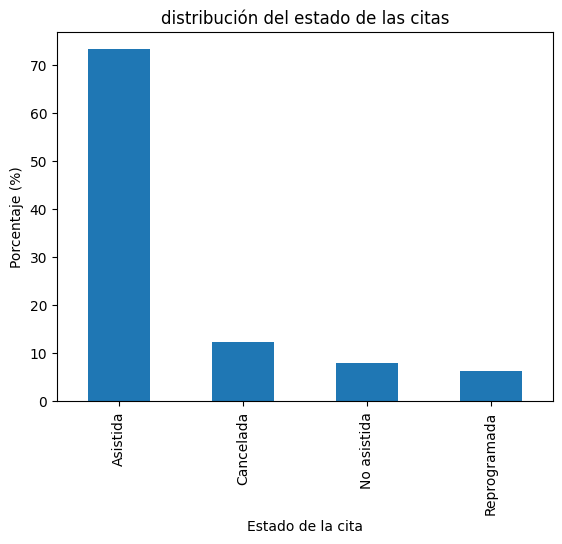

In [20]:
# Gráfico de barras para estado de cita
estado_cita_porcentaje.plot(kind="bar")

plt.title("distribución del estado de las citas")
plt.xlabel("Estado de la cita")
plt.ylabel("Porcentaje (%)")
plt.xticks
plt.show()

## Estado de las citas

Este análisis muestra la distribución de las citas según su estado final: asistidas, canceladas, no asistidas o reprogramadas.

La tasa de asistencia permite valorar el funcionamiento general de la agenda clínica, mientras que las cancelaciones y no asistencias son indicadores relevantes para la gestión administrativa y la optimización de recursos.

En el contexto del secretariado médico, estos resultados pueden ayudar a identificar oportunidades de mejora en la comunicación con pacientes, la gestión de recordatorios y la organización de la agenda.

In [21]:
# INDICADORES CONCRETOS
tasa_asistencia = estado_cita_porcentaje.get("Asistida", 0)
tasa_cancelacion = estado_cita_porcentaje.get("Cancelada", 0)
tasa_no_asistencia = estado_cita_porcentaje.get("No asistida", 0)
tasa_reprogramacion = estado_cita_porcentaje.get("Reprogramada", 0)

tasa_asistencia, tasa_cancelacion, tasa_no_asistencia, tasa_reprogramacion

(np.float64(73.25), np.float64(12.38), np.float64(8.06), np.float64(6.31))

In [22]:
# CREAMOS TABLA CON LOS INDICADORES
indicadores_citas = pd.DataFrame(
    {"Indicador": ["Tasa de asistencia","Tasa de cancelación","Tasa de no asistencia","Tasa de reprogramación",],
    "Porcentaje": [tasa_asistencia,tasa_cancelacion,tasa_no_asistencia,tasa_reprogramacion,],})

indicadores_citas

,Indicador,Porcentaje
0,Tasa de asistencia,73.25
1,Tasa de cancelación,12.38
2,Tasa de no asistencia,8.06
3,Tasa de reprogramación,6.31


# BLOQUE 3: RECORDATORIOS Y ASISTENCIA
¿Enviar recordatorios está relacionado con una mayor asistencia y menos no asistencia?

In [23]:
# CONTEO DE RECORDATORIOS ENVIADOS
df["recordatorio_enviado"].value_counts()

recordatorio_enviado
Sí    1185
No     415
Name: count, dtype: int64

In [24]:
#PORCENTAJE DE RECORDATORIOS ENVIADOS
recordatorio_porcentaje = df["recordatorio_enviado"].value_counts(normalize=True).round(4) * 100
recordatorio_porcentaje= recordatorio_porcentaje.round(2)
recordatorio_porcentaje

recordatorio_enviado
Sí    74.06
No    25.94
Name: proportion, dtype: float64

In [25]:
# HACEMOS UNA TABLA CRUZADA: RECORDATORIO ENVIADO VS ESTADO DE CITA
recordatorio_estado= pd. crosstab(df["recordatorio_enviado"], df["estado_cita"], normalize="index") * 100
recordatorio_estado= recordatorio_estado.round(2)
recordatorio_estado

estado_cita,Asistida,Cancelada,No asistida,Reprogramada
recordatorio_enviado,,,,
No,60.48,16.39,17.11,6.02
Sí,77.72,10.97,4.89,6.41


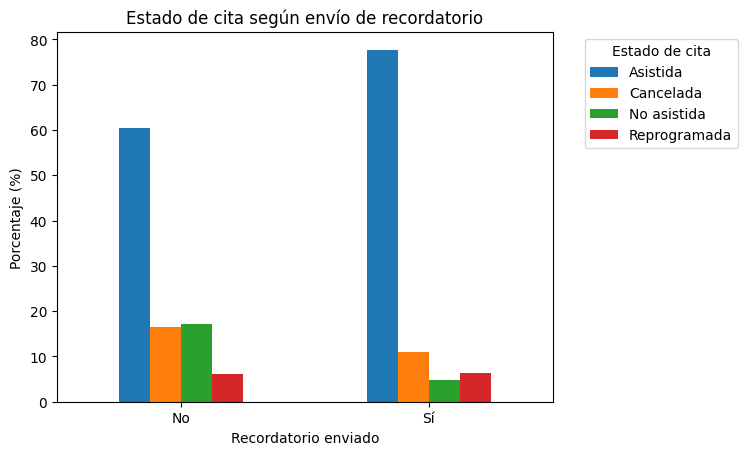

In [26]:
# GRAFICO 
recordatorio_estado.plot(kind= "bar")

plt.title("Estado de cita según envío de recordatorio")
plt.xlabel("Recordatorio enviado")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(title="Estado de cita", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Recordatorios y asistencia

Este análisis compara el estado final de las citas en función de si se envió o no un recordatorio previo.

El objetivo es valorar si los recordatorios podrían estar asociados con una mayor tasa de asistencia y una menor tasa de no asistencia. Desde la perspectiva del secretariado médico, este resultado puede ser útil para justificar la automatización de recordatorios por WhatsApp, email o llamada telefónica.

Aunque el dataset es sintético, el análisis reproduce una situación habitual en centros sanitarios: reducir ausencias y mejorar la eficiencia de la agenda clínica.

# BLOQUE 4: MOTIVO DE CONSULTA 

In [27]:
# CONTEO DE MOTIVOS DE CONSULTA
df["motivo_consulta"].value_counts()

motivo_consulta
Ansiedad                342
Estrés laboral          268
Duelo                   254
Orientación familiar    174
Depresión leve          169
Autoestima              164
Problemas de pareja     131
Estrés académico         98
Name: count, dtype: int64

In [28]:
# PORCENTAJE DE MOTIVOS DE CONSULTA
motivo_porcentaje = df["motivo_consulta"].value_counts(normalize=True).round(4) * 100
motivo_porcentaje = motivo_porcentaje.round(2)
motivo_porcentaje

motivo_consulta
Ansiedad                21.38
Estrés laboral          16.75
Duelo                   15.88
Orientación familiar    10.88
Depresión leve          10.56
Autoestima              10.25
Problemas de pareja      8.19
Estrés académico         6.12
Name: proportion, dtype: float64

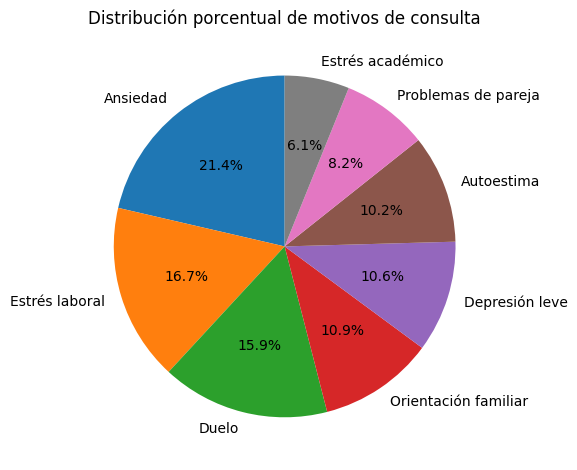

In [29]:
# GRAFICO DE MOTIVOS DE CONSULTA
motivo_porcentaje.plot(kind="pie", autopct="%1.1f%%", startangle=90)

plt.title("Distribución porcentual de motivos de consulta")
plt.ylabel("")
plt.tight_layout()
plt.show()

### CRUZAR EL MOTIVO DE CONSULTA CON NIVEL DE URGENCIA 
¿Qué motivos de consulta aparecen más asociados a urgencia baja, media o alta?

In [30]:
motivo_urgencia = (
    pd.crosstab(df["motivo_consulta"], df["nivel_urgencia"], normalize="index") * 100)
motivo_urgencia = motivo_urgencia.round(2)
motivo_urgencia

nivel_urgencia,Alto,Bajo,Medio
motivo_consulta,,,
Ansiedad,24.27,15.20,60.53
Autoestima,20.12,44.51,35.37
Depresión leve,18.34,17.16,64.50
Duelo,23.62,34.25,42.13
Estrés académico,18.37,30.61,51.02
Estrés laboral,11.94,49.25,38.81
Orientación familiar,10.34,55.75,33.91
Problemas de pareja,10.69,57.25,32.06


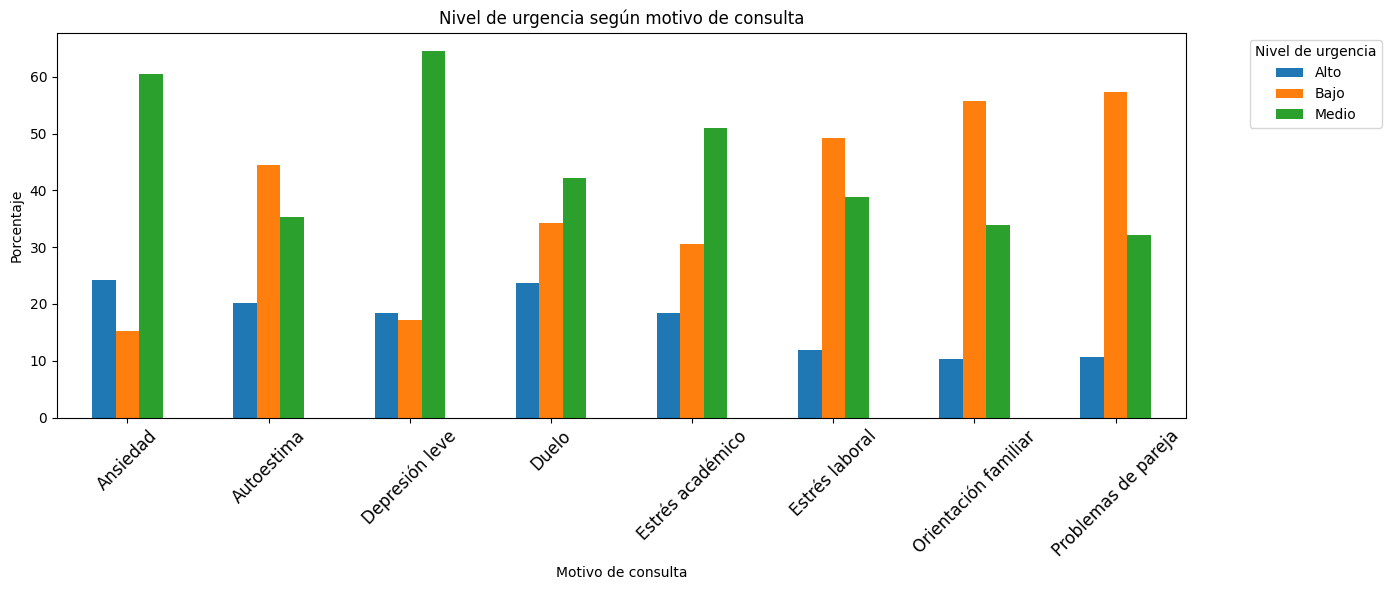

In [31]:
# GRAFICO DE MOTIVO CONSULTA VS NIVEL DE URGENCIA

motivo_urgencia.plot(kind="bar",figsize=(14, 6))

plt.title("Nivel de urgencia según motivo de consulta")
plt.xlabel("Motivo de consulta")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Nivel de urgencia", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Motivos de consulta y nivel de urgencia

Este análisis permite observar cómo se distribuyen los niveles de urgencia según el motivo principal de consulta.

Desde la perspectiva psicológica, esta información ayuda a identificar qué demandas pueden requerir una atención más prioritaria. Desde la perspectiva del secretariado médico, puede ser útil para organizar la agenda, priorizar primeras citas y mejorar la planificación de recursos.

Al tratarse de un dataset sintético, los resultados no representan evidencia clínica real, sino una simulación útil para practicar análisis de datos aplicado a una clínica psicológica.

# BLOQUE 5: ANÁLISIS DE CONTINUIDAD TERAPÉUTICA 
¿Qué porcentaje de pacientes continúa, abandona, recibe alta terapéutica o es derivado?

In [32]:
# CONTEO DE CONTINUIDAD
df["continuidad"].value_counts()

continuidad
Continúa            1057
Abandona             330
Alta terapéutica     110
Derivación           103
Name: count, dtype: int64

In [33]:
# PORCENTAJE DE CONTINUIDAD
continuidad_porcentaje = df["continuidad"].value_counts(normalize=True).round(4) * 100
continuidad_porcentaje = continuidad_porcentaje.round(2)
continuidad_porcentaje

continuidad
Continúa            66.06
Abandona            20.62
Alta terapéutica     6.88
Derivación           6.44
Name: proportion, dtype: float64

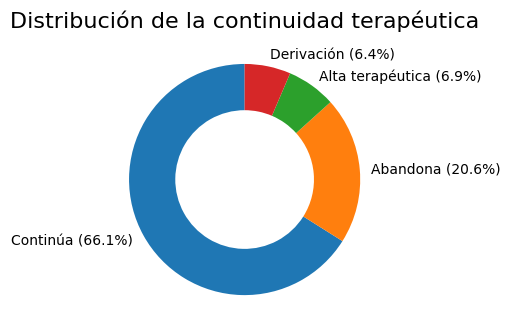

In [34]:
# GRÁFICO
etiquetas = [
    f"{nombre} ({valor:.1f}%)" for nombre, valor in continuidad_porcentaje.items()
]

continuidad_porcentaje.plot(kind="pie", labels= etiquetas,startangle=90, figsize=(5, 5),wedgeprops={"width": 0.4},)

plt.title("Distribución de la continuidad terapéutica", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

## Continuidad terapéutica

Este análisis muestra la distribución de los procesos terapéuticos según su estado de continuidad: pacientes que continúan, abandonan, reciben alta terapéutica o son derivados a otro recurso.

Desde la perspectiva psicológica, la continuidad terapéutica es un indicador relevante para estudiar la adherencia al tratamiento. Desde la perspectiva administrativa, permite detectar posibles puntos de mejora en el seguimiento de pacientes y en la gestión de citas.

Al tratarse de un dataset sintético, los resultados deben interpretarse como una simulación para practicar análisis de datos en un contexto sanitario.

## cruzamos continuidad con días de espera
¿Los pacientes que abandonan tuvieron más días de espera antes de la cita?

In [35]:
# tabla resumen 
df.groupby("continuidad")["dias_espera"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
continuidad,,,,,,,,
Abandona,330.0,11.27,7.02,1.0,6.0,10.0,15.0,30.0
Alta terapéutica,110.0,12.09,7.46,1.0,7.0,11.0,15.0,30.0
Continúa,1057.0,11.86,7.27,1.0,6.0,10.0,15.0,30.0
Derivación,103.0,12.44,7.78,1.0,6.0,11.0,16.0,30.0


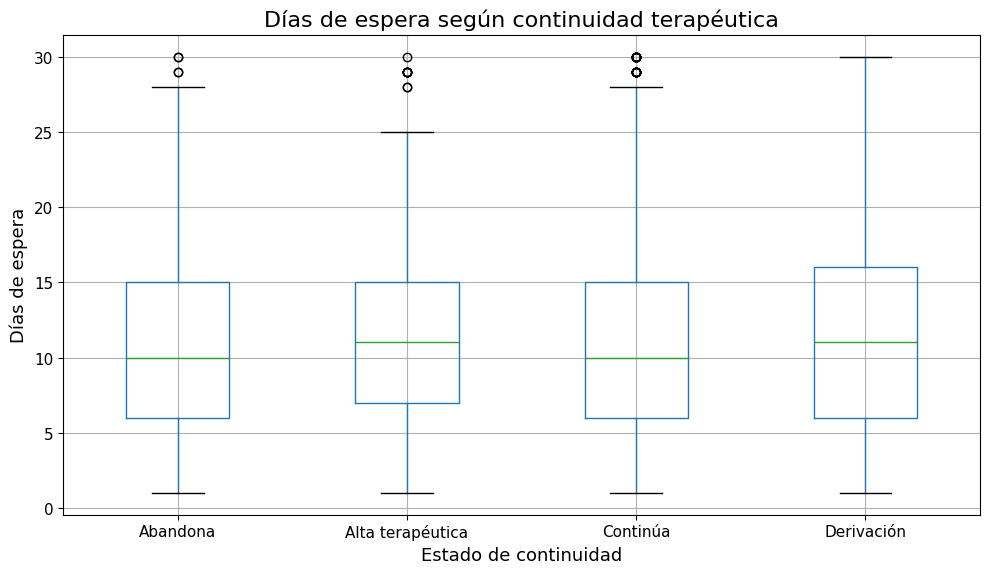

In [36]:
# grafico días de espera seún continuidad
df.boxplot(column="dias_espera", by="continuidad", figsize=(10, 6))

plt.title("Días de espera según continuidad terapéutica", fontsize=16)
plt.suptitle("")
plt.xlabel("Estado de continuidad", fontsize=13)
plt.ylabel("Días de espera", fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### Continuidad terapéutica y días de espera

Este análisis compara los días de espera hasta la cita según el estado de continuidad terapéutica.

El objetivo es explorar si los tiempos de espera más largos podrían estar asociados con una mayor probabilidad de abandono. Desde la gestión administrativa, este indicador es relevante porque permite valorar si reducir el tiempo entre la solicitud y la cita podría mejorar la adherencia al proceso terapéutico.

El gráfico de caja permite observar la distribución de los días de espera en cada grupo de continuidad, incluyendo la mediana, la dispersión y posibles valores extremos.

# BLOQUE 6: ANÁLISIS TEMPORAL DE CITAS


In [37]:
df["anio"] = df["fecha_cita"].dt.year
df["mes"] = df["fecha_cita"].dt.to_period("M")

In [38]:
# CONTAR CITAS POR MES
citas_por_mes = df.groupby("mes").size()

citas_por_mes

mes
2024-01     40
2024-02     74
2024-03     53
2024-04     77
2024-05     72
2024-06     53
2024-07     77
2024-08     61
2024-09     57
2024-10     57
2024-11     62
2024-12     53
2025-01     65
2025-02     80
2025-03     54
2025-04     72
2025-05     71
2025-06     61
2025-07     79
2025-08     77
2025-09     72
2025-10     65
2025-11     66
2025-12    102
Freq: M, dtype: int64

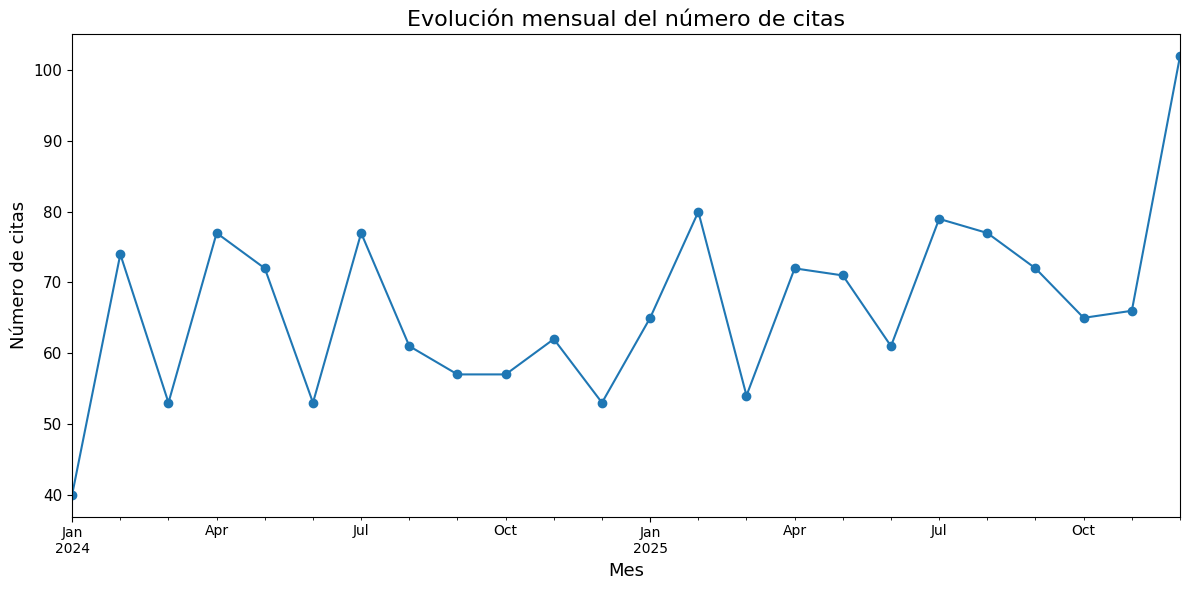

In [40]:
# GRÁFICO DE EVOLUCIÓN DE CITAS POR MES
citas_por_mes.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Evolución mensual del número de citas", fontsize=16)
plt.xlabel("Mes", fontsize=13)
plt.ylabel("Número de citas", fontsize=13)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [41]:
# COMPARACIÓN DE CITAS POR AÑOS
citas_por_anio = df["anio"].value_counts().sort_index()

citas_por_anio

anio
2024    736
2025    864
Name: count, dtype: int64

In [42]:
# EM PORCENTAJE
citas_por_anio_porcentaje = df["anio"].value_counts(normalize=True).sort_index() * 100
citas_por_anio_porcentaje.round(2)

anio
2024    46.0
2025    54.0
Name: proportion, dtype: float64

In [43]:
# TABLA RESUMEN POR AÑO
resumen_anual = pd.DataFrame(
    {
        "Año": citas_por_anio.index,
        "Número de citas": citas_por_anio.values,
        "Porcentaje": citas_por_anio_porcentaje.round(2).values,
    }
)

resumen_anual

,Año,Número de citas,Porcentaje
0,2024,736,46.0
1,2025,864,54.0


## Evolución temporal de las citas

Este análisis muestra la distribución de citas a lo largo del periodo 2024-2025.

El gráfico de líneas permite observar la evolución mensual de la actividad de la clínica, identificando posibles meses con mayor o menor volumen de citas. Además, la comparación anual permite valorar si la actividad se mantiene equilibrada entre ambos años o si existe una mayor concentración de citas en alguno de ellos.

Desde la perspectiva del secretariado médico, este análisis puede ayudar a planificar la agenda, anticipar periodos de mayor demanda y organizar mejor los recursos disponibles.

# BLOQUE 7: EVOLUCIÓN DE CANCELACIONES Y NO ASISTENCIAS
¿Cómo evolucionan las cancelaciones y las no asistencias a lo largo del tiempo?

In [44]:
# CREAR TABLA DE ESTADOS DE CITA POR MES
estado_por_mes = pd.crosstab(df["mes"], df["estado_cita"])

estado_por_mes

estado_cita,Asistida,Cancelada,No asistida,Reprogramada
mes,,,,
2024-01,30,7,2,1
2024-02,55,12,6,1
2024-03,40,3,8,2
2024-04,54,8,9,6
2024-05,50,10,5,7
2024-06,42,4,5,2
2024-07,64,6,3,4
2024-08,42,10,6,3
2024-09,47,7,2,1


In [45]:
# LO PASAMOS A PORCENTAJE
estado_por_mes_porcentaje = (pd.crosstab(df["mes"], df["estado_cita"], normalize="index") * 100)

estado_por_mes_porcentaje = estado_por_mes_porcentaje.round(2)

estado_por_mes_porcentaje

estado_cita,Asistida,Cancelada,No asistida,Reprogramada
mes,,,,
2024-01,75.00,17.50,5.00,2.50
2024-02,74.32,16.22,8.11,1.35
2024-03,75.47,5.66,15.09,3.77
2024-04,70.13,10.39,11.69,7.79
2024-05,69.44,13.89,6.94,9.72
2024-06,79.25,7.55,9.43,3.77
2024-07,83.12,7.79,3.90,5.19
2024-08,68.85,16.39,9.84,4.92
2024-09,82.46,12.28,3.51,1.75


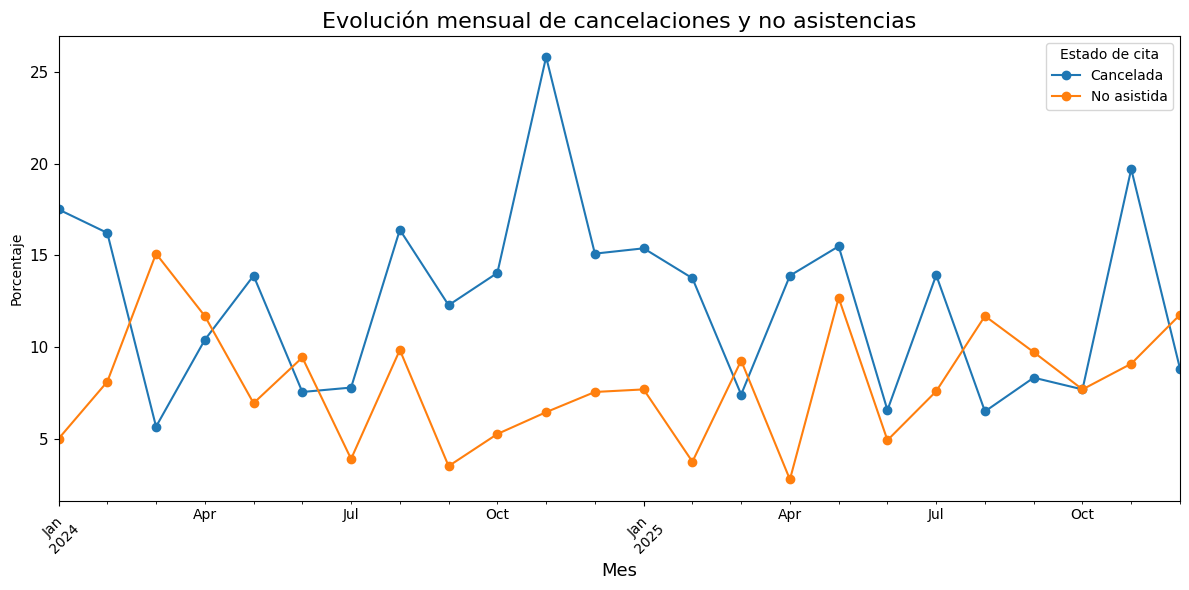

In [46]:
# GRÁFICO DE LINEAS APRA CANCELACIONES Y NO ASISTENCIAS
estado_por_mes_porcentaje[["Cancelada", "No asistida"]].plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Evolución mensual de cancelaciones y no asistencias", fontsize=16)
plt.xlabel("Mes", fontsize=13)
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=11)
plt.legend(title="Estado de cita")
plt.tight_layout()
plt.show()

Este análisis muestra cómo evolucionan las cancelaciones y las no asistencias a lo largo del periodo analizado.

Desde la perspectiva del secretariado médico, este indicador permite identificar meses en los que la agenda clínica puede verse más afectada por ausencias o cambios de cita. Detectar estos patrones puede ayudar a reforzar los recordatorios, ajustar la planificación de la agenda o revisar los canales de comunicación con los pacientes.

El análisis temporal de cancelaciones y no asistencias aporta información útil para mejorar la eficiencia administrativa de la clínica.

In [48]:
# DETECTAR EL MES CON MAYOR TASA DE NO ASISTENCIA
mes_mayor_no_asistencia = estado_por_mes_porcentaje["No asistida"].idxmax()
porcentaje_mas_no_asistencia = estado_por_mes_porcentaje["No asistida"].max()
mes_mayor_no_asistencia, porcentaje_mas_no_asistencia

(Period('2024-03', 'M'), np.float64(15.09))

In [49]:
# para cancelaciones
mes_mas_cancelaciones = estado_por_mes_porcentaje["Cancelada"].idxmax()
porcentaje_mas_cancelaciones = estado_por_mes_porcentaje["Cancelada"].max()

mes_mas_cancelaciones, porcentaje_mas_cancelaciones

(Period('2024-11', 'M'), np.float64(25.81))

el mes con mayor porcentaje de no asistencias fue marzo de 2024, mientras que le mes con mayor porcentaje de cancelaciones fue noviembre de 2024

# BLOQUE 8: ANÁLISIS POR CANAL DE RESERVA
¿Qué canal de reserva tiene mejor tasa de asistencia y menos no asistencias?

In [50]:
df["canal_reserva"].value_counts()

canal_reserva
WhatsApp    522
Web         438
Teléfono    402
Email       238
Name: count, dtype: int64

In [51]:
# PORCENTAJE DE CANALES DE RESERVA
canal_porcentaje = df["canal_reserva"].value_counts(normalize=True) * 100
canal_porcentaje = canal_porcentaje.round(2)

canal_porcentaje

canal_reserva
WhatsApp    32.62
Web         27.38
Teléfono    25.12
Email       14.88
Name: proportion, dtype: float64

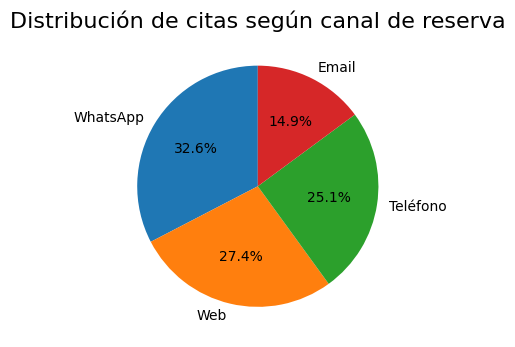

In [53]:
# GRÁFICO CIRCULAR DE CANALES
canal_porcentaje.plot(kind="pie", autopct="%1.1f%%", startangle=90, figsize=(4, 4))

plt.title("Distribución de citas según canal de reserva", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [56]:
# CANAL DE RESERVA VS ESTADO DE CITA
canal_estado = pd.crosstab(df["canal_reserva"], df["estado_cita"], normalize="index") * 100
canal_estado = canal_estado.round(2)
canal_estado

estado_cita,Asistida,Cancelada,No asistida,Reprogramada
canal_reserva,,,,
Email,70.17,14.29,9.66,5.88
Teléfono,73.63,12.44,7.96,5.97
Web,72.15,12.33,9.36,6.16
WhatsApp,75.29,11.49,6.32,6.90


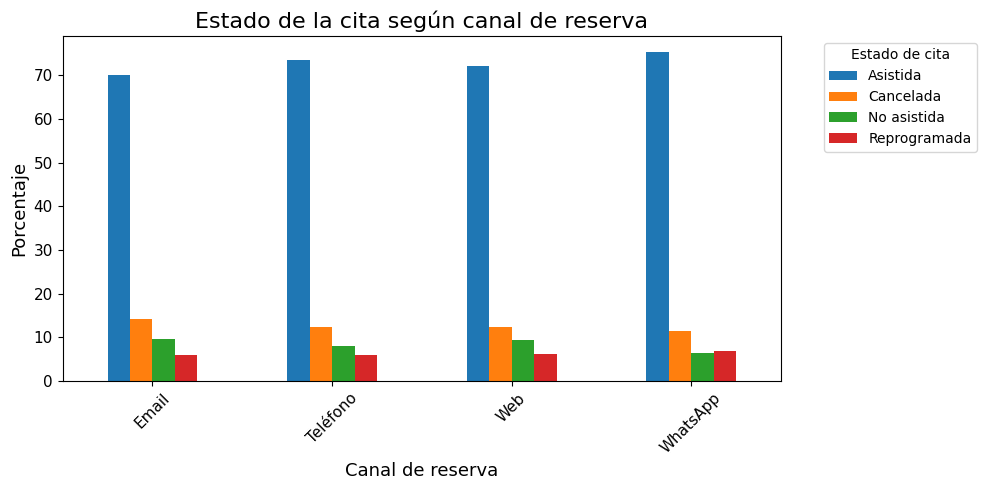

In [58]:
# GRAFICO CANAL DE RESERVA VS ESTADO DE CITA
canal_estado.plot(kind="bar", figsize=(10, 5))

plt.title("Estado de la cita según canal de reserva", fontsize=16)
plt.xlabel("Canal de reserva", fontsize=13)
plt.ylabel("Porcentaje", fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Estado de cita", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Este análisis permite observar qué canales de reserva son más utilizados por los pacientes y cómo se relacionan con el estado final de la cita.
Conocer qué canales presentan mayor tasa de asistencia o menor tasa de no asistencia puede ayudar a mejorar la comunicación con los pacientes y optimizar la gestión de agenda.

Además, este análisis puede orientar decisiones sobre qué canales conviene potenciar, automatizar o revisar dentro de la clínica.

# BLOQUE 9: MODALIAD ONLINE VS PRESENCIAL 
¿Hay diferencias entre las citas online y presenciales en asistencia, satisfacción y continuidad?

In [59]:
df["modalidad"].value_counts()

modalidad
Presencial    900
Online        700
Name: count, dtype: int64

In [60]:
# PORCENTAJE
modalidad_porcentaje = df["modalidad"].value_counts(normalize=True) * 100
modalidad_porcentaje = modalidad_porcentaje.round(2)

modalidad_porcentaje

modalidad
Presencial    56.25
Online        43.75
Name: proportion, dtype: float64

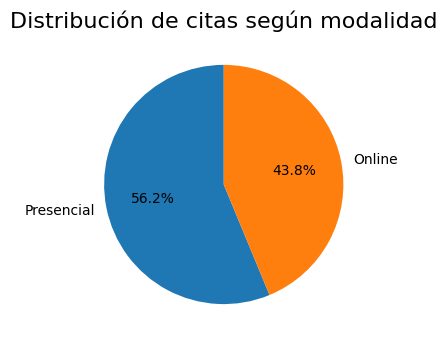

In [62]:
# GRÁFICO
modalidad_porcentaje.plot(kind="pie", autopct="%1.1f%%", startangle=90, figsize=(4, 4))

plt.title("Distribución de citas según modalidad", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [63]:
# MODALIDAD VS ESTADO DE CITA
modalidad_estado = (pd.crosstab(df["modalidad"], df["estado_cita"], normalize="index") * 100)
modalidad_estado = modalidad_estado.round(2)
modalidad_estado

estado_cita,Asistida,Cancelada,No asistida,Reprogramada
modalidad,,,,
Online,75.43,11.00,7.29,6.29
Presencial,71.56,13.44,8.67,6.33


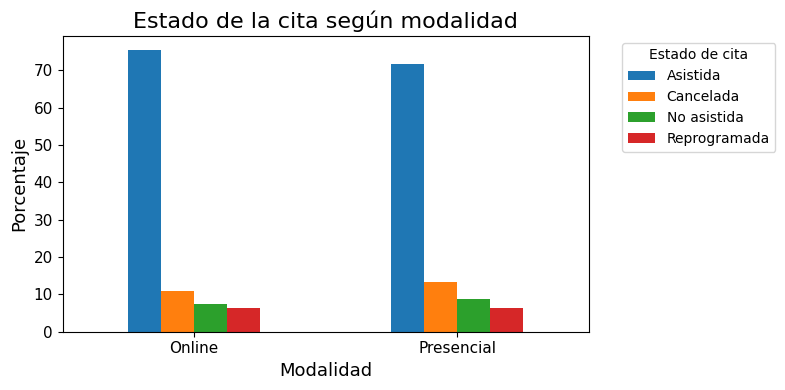

In [65]:
# GRÁFICO
modalidad_estado.plot(kind="bar", figsize=(8, 4))

plt.title("Estado de la cita según modalidad", fontsize=16)
plt.xlabel("Modalidad", fontsize=13)
plt.ylabel("Porcentaje", fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Estado de cita", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [66]:
# SATISFACCIÓN
satisfaccion_modalidad = df.groupby("modalidad")["satisfaccion"].mean().round(2)

satisfaccion_modalidad

modalidad
Online        3.44
Presencial    3.42
Name: satisfaccion, dtype: float64

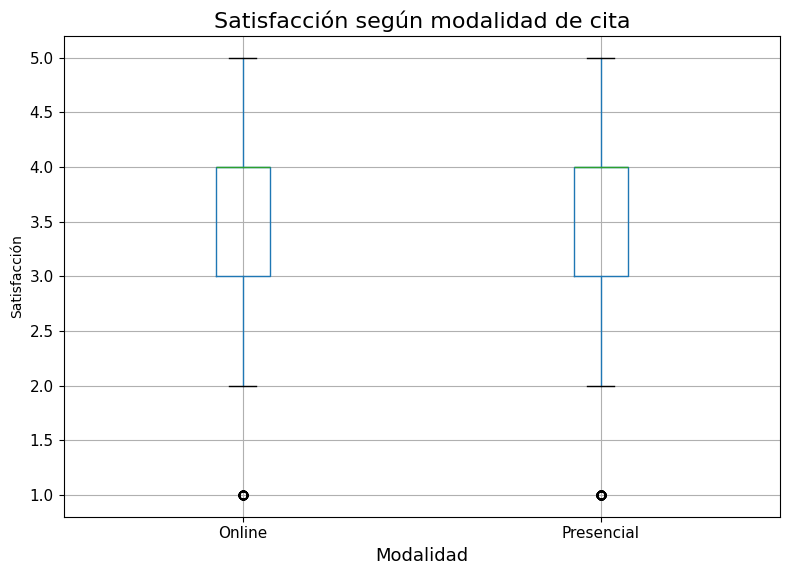

In [67]:
# GRÁFICO SATISFACCIÓN MEDIA POR MODALIDAD
df.boxplot(column="satisfaccion", by="modalidad", figsize=(8, 6))

plt.title("Satisfacción según modalidad de cita", fontsize=16)
plt.suptitle("")
plt.xlabel("Modalidad", fontsize=13)
plt.ylabel("Satisfacción")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Este análisis compara las citas online y presenciales en relación con el estado final de la cita y la satisfacción registrada.
Permite valorar si alguna modalidad presenta mayor tasa de asistencia, cancelación o no asistencia. Desde la perspectiva de experiencia del paciente, la satisfacción media por modalidad puede aportar información útil para adaptar la oferta de servicios.

En una clínica psicológica, este tipo de análisis puede ayudar a decidir si conviene potenciar la modalidad online, mantener la presencialidad o combinar ambas opciones según las necesidades de los pacientes.

# BLOQUE 10: PERFIL DE PACIENTE POR EDAD Y OCUPACIÓN 
¿Qué perfiles de pacientes acuden más a consulta y qué motivos predominan según ocupación o edad?

In [68]:
# CREAMOS GRUPOS DE EDAD
def grupo_edad(edad):
    if edad <= 25:
        return "18-25"
    elif edad <= 35:
        return "26-35"
    elif edad <= 45:
        return "36-45"
    elif edad <= 60:
        return "46-60"
    else:
        return "60+"

df["grupo_edad"] = df["edad"].apply(grupo_edad)

df[["edad", "grupo_edad"]].head()

,edad,grupo_edad
0,43,36-45
1,46,46-60
2,49,46-60
3,70,60+
4,49,46-60


In [69]:
# CONTEO POR GRUPO DE EDAD
df["grupo_edad"].value_counts().sort_index()

grupo_edad
18-25    229
26-35    189
36-45    298
46-60    420
60+      464
Name: count, dtype: int64

In [70]:
# PORCENTAJE DE GRUPO DE EDAD
grupo_edad_porcentaje = df["grupo_edad"].value_counts(normalize=True).sort_index() * 100
grupo_edad_porcentaje = grupo_edad_porcentaje.round(2)

grupo_edad_porcentaje

grupo_edad
18-25    14.31
26-35    11.81
36-45    18.62
46-60    26.25
60+      29.00
Name: proportion, dtype: float64

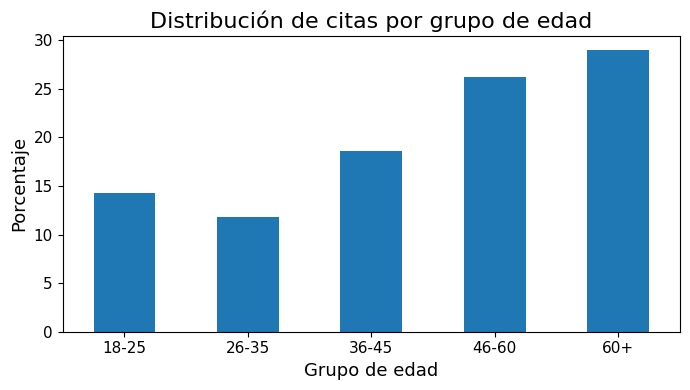

In [72]:
# GRÁFICO DE GFRUPO DE EDAD
grupo_edad_porcentaje.plot(kind="bar", figsize=(7, 4))

plt.title("Distribución de citas por grupo de edad", fontsize=16)
plt.xlabel("Grupo de edad", fontsize=13)
plt.ylabel("Porcentaje", fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [73]:
# MOTIVO DE CONSULTA POR GRUPO DE EDAD
edad_motivo = (pd.crosstab(df["grupo_edad"], df["motivo_consulta"], normalize="index") * 100)

edad_motivo = edad_motivo.round(2)

edad_motivo

motivo_consulta,Ansiedad,Autoestima,Depresión leve,Duelo,Estrés académico,Estrés laboral,Orientación familiar,Problemas de pareja
grupo_edad,,,,,,,,
18-25,22.71,16.59,7.42,4.37,30.13,2.18,12.23,4.37
26-35,28.04,6.88,5.29,8.99,4.23,28.57,4.23,13.76
36-45,14.09,11.07,12.08,5.37,2.68,36.24,6.04,12.42
46-60,28.33,10.95,12.62,10.71,3.10,20.00,4.05,10.24
60+,16.38,7.33,11.42,35.78,0.00,3.66,22.20,3.23


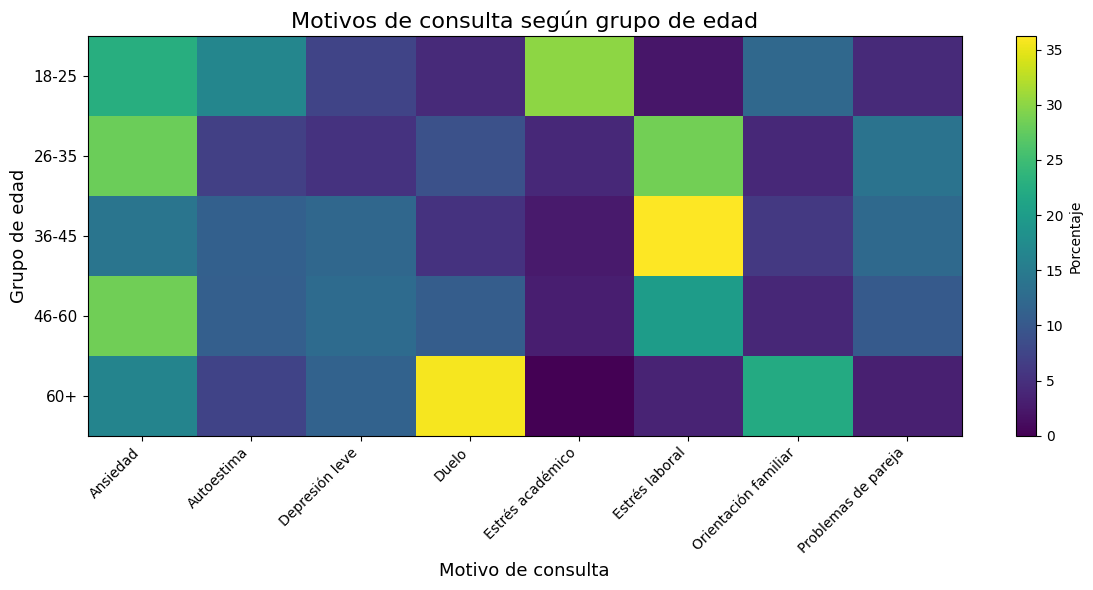

In [74]:
# GRÁFICO TIPO HEATMAP
plt.figure(figsize=(12, 6))

plt.imshow(edad_motivo, aspect="auto")

plt.title("Motivos de consulta según grupo de edad", fontsize=16)
plt.xlabel("Motivo de consulta", fontsize=13)
plt.ylabel("Grupo de edad", fontsize=13)

plt.xticks(
    ticks=range(len(edad_motivo.columns)),
    labels=edad_motivo.columns,
    rotation=45,
    ha="right",
    fontsize=10,
)

plt.yticks(ticks=range(len(edad_motivo.index)), labels=edad_motivo.index, fontsize=11)

plt.colorbar(label="Porcentaje")
plt.tight_layout()
plt.show()

In [75]:
# OCUPACIÓN DE LOS PACIENTES
ocupacion_porcentaje = df["ocupacion"].value_counts(normalize=True) * 100
ocupacion_porcentaje = ocupacion_porcentaje.round(2)

ocupacion_porcentaje

ocupacion
Empleado/a       31.56
Jubilado/a       27.44
Estudiante       12.81
Autónomo/a       12.44
Cuidador/a       10.06
Desempleado/a     5.69
Name: proportion, dtype: float64

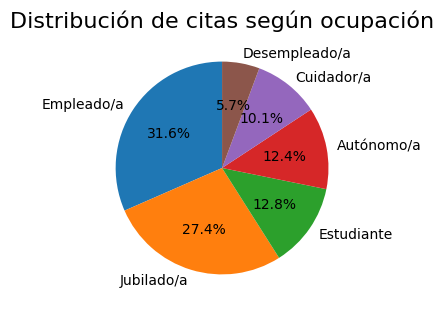

In [77]:
# GRÁFICO OCUPACIÓN 
ocupacion_porcentaje.plot(kind="pie", autopct="%1.1f%%", startangle=90, figsize=(4, 4))

plt.title("Distribución de citas según ocupación", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [78]:
# MOTIVO CONSULTA POR OCUPACIÓN
ocupacion_motivo = (pd.crosstab(df["ocupacion"], df["motivo_consulta"], normalize="index") * 100)

ocupacion_motivo = ocupacion_motivo.round(2)

ocupacion_motivo

motivo_consulta,Ansiedad,Autoestima,Depresión leve,Duelo,Estrés académico,Estrés laboral,Orientación familiar,Problemas de pareja
ocupacion,,,,,,,,
Autónomo/a,28.14,10.55,6.53,20.10,1.51,21.61,2.01,9.55
Cuidador/a,27.95,18.63,10.56,4.97,3.73,9.94,11.18,13.04
Desempleado/a,12.09,12.09,3.30,18.68,5.49,37.36,0.00,10.99
Empleado/a,19.60,9.50,11.49,8.51,6.34,26.53,5.35,12.67
Estudiante,28.78,14.63,5.37,3.90,25.37,4.39,14.63,2.93
Jubilado/a,16.40,5.47,15.26,31.44,0.00,7.29,21.64,2.51


Este análisis permite describir el perfil de pacientes atendidos en la clínica según grupo de edad y ocupación.

Desde la perspectiva psicológica, resulta útil para observar qué motivos de consulta predominan en diferentes etapas vitales o situaciones ocupacionales. Por ejemplo, los perfiles estudiantes pueden presentar mayor proporción de estrés académico o ansiedad, mientras que perfiles empleados pueden concentrar más casos relacionados con estrés laboral.

Desde la perspectiva administrativa, conocer el perfil de pacientes permite adaptar la comunicación, organizar horarios, planificar servicios y ajustar los recursos de la clínica a la demanda real observada.


# Conclusiones finales y recomendaciones

## Conclusiones finales

Este proyecto ha permitido analizar un dataset sintético de una clínica psicológica ficticia, combinando variables propias de la gestión administrativa de citas, la demanda psicológica y la continuidad terapéutica.

El dataset final contiene **1.600 citas** correspondientes a **392 pacientes únicos**, registradas entre el **3 de enero de 2024 y el 31 de diciembre de 2025**. No se detectaron valores nulos ni registros duplicados, por lo que la base de datos presenta una estructura limpia y adecuada para el análisis exploratorio.

### 1. Actividad general de la clínica

La clínica presenta una actividad repartida a lo largo de dos años, con una edad media de pacientes de **47,68 años**. El tiempo medio de espera entre la solicitud y la cita es de **11,79 días**, mientras que la satisfacción media registrada es de **3,43 sobre 5**.

Estos indicadores permiten obtener una primera visión global de la clínica y sirven como punto de partida para valorar la eficiencia de la agenda, la experiencia del paciente y la accesibilidad al servicio psicológico.

### 2. Estado de las citas

La mayoría de las citas fueron **asistidas**, con una tasa de asistencia del **73,25%**. Sin embargo, también se observa un porcentaje relevante de citas canceladas (**12,38%**), no asistidas (**8,06%**) y reprogramadas (**6,31%**).

Desde el punto de vista del secretariado médico, estos datos son importantes porque las cancelaciones y no asistencias afectan directamente a la organización de la agenda, al aprovechamiento del tiempo profesional y a la continuidad del proceso terapéutico.

### 3. Impacto de los recordatorios

El **74,06%** de las citas contaron con recordatorio previo, frente al **25,94%** que no lo tuvieron.

El análisis muestra una diferencia clara entre las citas con y sin recordatorio. Las citas con recordatorio presentan una tasa de asistencia del **77,72%**, mientras que las citas sin recordatorio presentan una tasa de asistencia del **60,48%**. Además, la no asistencia es mucho mayor cuando no se envía recordatorio (**17,11%**) que cuando sí se envía (**4,89%**).

Este resultado refuerza la importancia de los recordatorios como herramienta administrativa para mejorar la asistencia y reducir ausencias.

### 4. Motivos de consulta

Los motivos de consulta más frecuentes son **ansiedad** (**21,38%**), **estrés laboral** (**16,75%**) y **duelo** (**15,88%**). También aparecen motivos como orientación familiar, depresión leve, autoestima, problemas de pareja y estrés académico.

Este análisis permite entender mejor el tipo de demanda psicológica que recibe la clínica. La ansiedad aparece como el motivo principal más frecuente, lo que podría justificar la necesidad de contar con profesionales especializados en regulación emocional, manejo del estrés y acompañamiento psicológico.

### 5. Motivos de consulta y nivel de urgencia

Al cruzar los motivos de consulta con el nivel de urgencia, se observa que algunos motivos concentran mayor proporción de urgencia media o alta. Por ejemplo, ansiedad y depresión leve presentan porcentajes elevados de urgencia media, mientras que motivos como orientación familiar o problemas de pareja se concentran más en niveles de urgencia baja o media.

Este análisis puede ayudar a organizar mejor las primeras citas, priorizar determinados casos y mejorar la planificación de la agenda clínica.

### 6. Continuidad terapéutica

En relación con la continuidad terapéutica, el **66,06%** de los casos continúa el proceso, mientras que el **20,62%** abandona. Además, el **6,88%** alcanza alta terapéutica y el **6,44%** es derivado a otro recurso.

Aunque la mayoría de pacientes continúa, el porcentaje de abandono es un indicador relevante. Desde la perspectiva psicológica, la continuidad es clave para la adherencia al tratamiento. Desde la gestión administrativa, este dato puede servir para diseñar estrategias de seguimiento y prevención del abandono.

### 7. Días de espera y continuidad

El análisis de días de espera según continuidad muestra medias bastante similares entre los distintos grupos. Los pacientes que abandonan presentan una media de espera de **11,27 días**, los que continúan de **11,86 días**, los que reciben alta terapéutica de **12,09 días** y los derivados de **12,44 días**.

En este dataset sintético no se observa una diferencia muy marcada entre los días de espera y la continuidad terapéutica. Aun así, sigue siendo una variable importante para monitorizar, especialmente en primeras visitas o casos de mayor urgencia.

### 8. Evolución temporal

El análisis temporal muestra que en **2024** se registraron **736 citas** y en **2025** se registraron **864 citas**, lo que supone un mayor volumen de actividad en 2025.

A nivel mensual, diciembre de 2025 fue el mes con mayor número de citas, con **102 registros**. También se observan variaciones mensuales que podrían ser útiles para planificar la carga de trabajo, reforzar la agenda en determinados periodos y ajustar la disponibilidad de profesionales.

### 9. Cancelaciones y no asistencias a lo largo del tiempo

El análisis mensual de cancelaciones y no asistencias permite detectar meses especialmente relevantes. El mes con mayor porcentaje de no asistencias fue **marzo de 2024**, con un **15,09%**, mientras que el mes con mayor porcentaje de cancelaciones fue **noviembre de 2024**, con un **25,81%**.

Esta información puede ayudar a la clínica a reforzar recordatorios, revisar la comunicación previa con pacientes o analizar si existen factores estacionales que afecten a la asistencia.

### 10. Canales de reserva

El canal de reserva más utilizado fue **WhatsApp** (**32,62%**), seguido de **Web** (**27,38%**), **Teléfono** (**25,12%**) y **Email** (**14,88%**).

Además, WhatsApp presenta la mayor tasa de asistencia, con un **75,29%**, y una de las tasas más bajas de no asistencia, con un **6,32%**. Esto sugiere que los canales más directos y ágiles pueden favorecer una mejor comunicación con el paciente.

### 11. Modalidad online y presencial

La modalidad presencial representa el **56,25%** de las citas y la online el **43,75%**. Al comparar ambas modalidades, las citas online presentan una tasa de asistencia ligeramente superior (**75,43%**) frente a las presenciales (**71,56%**).

La satisfacción media es muy similar en ambas modalidades: **3,44** en online y **3,42** en presencial. Esto sugiere que ambas modalidades pueden convivir dentro de la clínica, ofreciendo flexibilidad sin afectar de forma significativa a la satisfacción del paciente.

### 12. Perfil de pacientes

Los grupos de edad con mayor presencia son **60+** (**29%**) y **46-60** (**26,25%**). En cuanto a ocupación, predominan los perfiles de **empleado/a** (**31,56%**) y **jubilado/a** (**27,44%**).

El análisis por grupo de edad muestra diferencias interesantes: en pacientes jóvenes destacan motivos como ansiedad y estrés académico, mientras que en pacientes mayores aparece con más frecuencia el duelo y la orientación familiar. Esto permite comprender mejor la demanda psicológica según etapa vital.

## Recomendaciones para la clínica

A partir del análisis realizado, se proponen las siguientes recomendaciones:

### 1. Mantener y automatizar los recordatorios de cita

Los datos muestran que las citas con recordatorio tienen una tasa de asistencia mucho mayor y una tasa de no asistencia más baja. Por ello, se recomienda mantener un sistema de recordatorios automáticos antes de cada cita, especialmente mediante WhatsApp, email o SMS.

Esta medida puede mejorar la organización de la agenda, reducir huecos improductivos y facilitar la continuidad del proceso terapéutico.

### 2. Potenciar WhatsApp como canal de comunicación

WhatsApp es el canal de reserva más utilizado y presenta buenos resultados en asistencia. Se recomienda potenciar este canal mediante mensajes automatizados, confirmaciones de cita, recordatorios y opciones sencillas de reprogramación.

También sería recomendable revisar el canal de email, ya que es el menos utilizado y presenta una tasa de asistencia algo inferior.

### 3. Revisar los meses con mayor tasa de ausencias

Marzo de 2024 destaca por el mayor porcentaje de no asistencias, mientras que noviembre de 2024 presenta el mayor porcentaje de cancelaciones. La clínica podría revisar estos periodos para identificar posibles causas y reforzar la comunicación previa con los pacientes.

Una medida útil sería aplicar recordatorios adicionales o confirmaciones activas en meses donde históricamente se detecten más ausencias.

### 4. Monitorizar el abandono terapéutico

Aunque la mayoría de pacientes continúa el proceso, el abandono representa un **20,62%**. Se recomienda crear un sistema de seguimiento para pacientes con mayor riesgo de abandono, especialmente aquellos con no asistencias, cancelaciones repetidas o baja satisfacción.

Este seguimiento podría incluir llamadas de confirmación, mensajes personalizados o facilidades para reprogramar citas.

### 5. Mantener una oferta combinada online y presencial

La modalidad online presenta una tasa de asistencia ligeramente superior y una satisfacción muy similar a la presencial. Por tanto, se recomienda mantener ambas modalidades para ofrecer flexibilidad a los pacientes.

La opción online puede ser especialmente útil para pacientes con dificultades de desplazamiento, problemas de agenda o necesidad de mayor conciliación.

### 6. Priorizar casos según motivo y urgencia

El análisis de motivos de consulta y nivel de urgencia puede ayudar a organizar mejor las primeras citas. Motivos como ansiedad, depresión leve o duelo podrían requerir una revisión más prioritaria dentro de la agenda.

Esta priorización debe entenderse como una ayuda administrativa inicial y no como sustitución de la valoración clínica profesional.

### 7. Adaptar servicios al perfil de pacientes

Dado que los grupos de mayor edad y los perfiles empleados y jubilados tienen una presencia importante en el dataset, la clínica podría adaptar horarios, comunicación y servicios a estos perfiles.

Por ejemplo, se podrían ofrecer horarios compatibles con jornada laboral para personas empleadas y programas específicos relacionados con duelo, adaptación vital u orientación familiar para pacientes mayores.

### 8. Crear un dashboard de seguimiento interno

Se recomienda crear un dashboard con indicadores clave como:

- tasa de asistencia,
- tasa de cancelación,
- tasa de no asistencia,
- evolución mensual de citas,
- motivos de consulta,
- nivel de urgencia,
- canal de reserva,
- modalidad,
- continuidad terapéutica,
- satisfacción media.

Este dashboard permitiría a la clínica tomar decisiones basadas en datos y revisar periódicamente la evolución de la actividad.

## Reflexión final

Este proyecto muestra cómo el análisis de datos puede aplicarse a un contexto psicológico y sanitario para mejorar la gestión de citas, comprender la demanda asistencial y apoyar la toma de decisiones administrativas.

A través de este análisis se integran tres áreas clave: la psicología, el secretariado médico y el análisis de datos. La psicología aporta la comprensión de los motivos de consulta y la continuidad terapéutica; el secretariado médico aporta la visión de agenda, recordatorios, canales de reserva y atención al paciente; y el análisis de datos permite transformar esa información en indicadores útiles para la mejora de la clínica.

Aunque los datos utilizados son sintéticos, el proyecto reproduce situaciones habituales en un centro psicológico: gestión de citas, ausencias, cancelaciones, tiempos de espera, seguimiento de pacientes y organización de recursos.

Por tanto, CliniMind Analytics funciona como una propuesta de portfolio orientada a demostrar cómo los datos pueden ayudar a mejorar tanto la experiencia del paciente como la eficiencia administrativa de una clínica de salud mental.